# 🎛️ Classical PID Tuning Methods (MATLAB Simulink Style)

> **Implementation of methods from MATLAB Simulink PID Tuner**

## 📋 Implemented Methods

| # | Method | Description |
|---|-------|----------|
| 1 | **Ziegler-Nichols** | Classical step response method |
| 2 | **Cohen-Coon** | Improved method for FOPDT systems |
| 3 | **SIMC (Skogestad)** | Modern robust method |
| 4 | **CHR** | Criterion-based method (0% and 20% overshoot) |
| 5 | **Lambda/IMC** | Internal model control method |
| 6 | **AMIGO** | Optimal performance/robustness trade-off |

In [ ]:
## 📦 Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from scipy.optimize import curve_fit, minimize_scalar, minimize
from scipy.signal import find_peaks, TransferFunction, bode, step, lti
from scipy import signal
from dataclasses import dataclass
from typing import Dict, Tuple, Optional
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

from tensoraerospace.agent.pid import PID
from tensoraerospace.utils import generate_time_period, convert_tp_to_sec_tp
from tensoraerospace.signals.standart import unit_step
from tensoraerospace.benchmark.function import (
    overshoot, settling_time, static_error,
    integral_squared_error, integral_absolute_error,
    integral_time_absolute_error, rise_time
)

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

print("✅ Libraries loaded")

✅ Библиотеки загружены


In [2]:
## ⚙️ Data structures

In [3]:
@dataclass
class FOPDTParams:
    """First-order plus dead time (FOPDT) model parameters.
    G(s) = K * exp(-θs) / (τs + 1)
    """
    K: float      # Static gain
    tau: float    # Time constant (τ)
    theta: float  # Dead time (θ)
    
    def __repr__(self):
        # Convert to float in case it's a numpy scalar
        K = float(self.K) if hasattr(self.K, 'item') else float(self.K)
        tau = float(self.tau) if hasattr(self.tau, 'item') else float(self.tau)
        theta = float(self.theta) if hasattr(self.theta, 'item') else float(self.theta)
        return f"FOPDT: K={K:.4f}, τ={tau:.4f}s, θ={theta:.4f}s"

@dataclass 
class PIDParams:
    """PID controller parameters."""
    Kp: float
    Ki: float
    Kd: float
    method: str = ""
    
    @property
    def Ti(self) -> float:
        ki = float(self.Ki)
        kp = float(self.Kp)
        return kp / ki if ki != 0 else float('inf')
    
    @property
    def Td(self) -> float:
        kp = float(self.Kp)
        kd = float(self.Kd)
        return kd / kp if kp != 0 else 0
    
    def __repr__(self):
        kp = float(self.Kp)
        ki = float(self.Ki)
        kd = float(self.Kd)
        return f"{self.method}: Kp={kp:.4f}, Ki={ki:.4f}, Kd={kd:.4f}"

@dataclass
class SimulationResult:
    """Simulation results."""
    time: np.ndarray
    reference: np.ndarray
    response: np.ndarray
    settling_time: float
    overshoot: float
    static_error: float
    rise_time: float
    ise: float
    iae: float
    itae: float

print("✅ Data structures defined")

✅ Структуры данных определены


In [4]:
## 🔧 PIDTuner class - the tuning foundation

In [5]:
class PIDTuner:
    """Class for tuning a PID controller with classic MATLAB Simulink methods."""
    
    def __init__(self, env_id: str, dt: float = 0.01, tn: float = 30.0,
                 track_state: str = 'alpha', step_deg: float = 5.0, 
                 step_time: float = 10.0):
        """
        Args:
            env_id: Gymnasium environment ID
            dt: Discretization step (sec)
            tn: Total simulation time (sec)
            track_state: Tracked state
            step_deg: Step signal amplitude (degrees)
            step_time: Time of the step (sec)
        """
        self.env_id = env_id
        self.dt = dt
        self.tn = tn
        self.track_state = track_state
        self.step_deg = step_deg
        self.step_time = step_time
        self.step_time_idx = int(step_time / dt)  # Step index
        
        self.tp = generate_time_period(tn=tn, dt=dt)
        self.tps = convert_tp_to_sec_tp(self.tp, dt=dt)
        self.number_time_steps = len(self.tp)
        
        self.reference_signals = np.reshape(
            unit_step(degree=step_deg, tp=self.tp, time_step=self.step_time_idx, output_rad=True), [1, -1])
        
        print(f"📊 Simulation parameters:")
        print(f"   Simulation time: {tn} s, step: {dt} s")
        print(f"   Step: {step_deg}° at t = {step_time} s (index {self.step_time_idx})")
        
        self.fopdt_params: Optional[FOPDTParams] = None
        self.tuning_results: Dict[str, PIDParams] = {}
        
    def _create_env(self):
        return gym.make(self.env_id, number_time_steps=self.number_time_steps,
            initial_state=[[0], [0], [0]], reference_signal=self.reference_signals,
            state_space=["theta", "alpha", "q"], output_space=["theta", "alpha", "q"],
            tracking_states=[self.track_state], use_reward=False)
    
    def get_step_response(self, input_amplitude: float = 1.0):
        """Obtain the system step response."""
        env = self._create_env()
        env.reset()
        response = []
        for step in range(self.number_time_steps - 2):
            # The step occurs at step_time_idx
            u = np.array([input_amplitude]) if step > self.step_time_idx else np.array([0.0])
            xt, _, _, _, _ = env.step(u)
            response.append(xt[0])
        return self.tps[:len(response)], np.array(response)
    
    def identify_fopdt(self) -> FOPDTParams:
        """Identify FOPDT model parameters using the two-point method (28.3% and 63.2%)."""
        print("📊 Identifying FOPDT model parameters...")
        time, response = self.get_step_response(input_amplitude=1.0)
        y0 = float(response[0])
        y_final = float(np.mean(response[-100:]))
        K = y_final - y0
        
        if abs(K) < 1e-10:
            K = 1.0  # Guard against division by zero
        
        y_norm = (response - y0) / K
        
        t1_idx = int(np.argmax(y_norm >= 0.283))
        t2_idx = int(np.argmax(y_norm >= 0.632))
        t1 = float(time[t1_idx])
        t2 = float(time[t2_idx])
        
        tau = 1.5 * (t2 - t1)
        theta = max(0.001, t2 - tau)  # Minimum dead time to avoid division by zero
        
        self.fopdt_params = FOPDTParams(K=float(K), tau=float(tau), theta=float(theta))
        print(f"   ✅ {self.fopdt_params}")
        return self.fopdt_params

    # ========== TUNING METHODS ==========
    
    def ziegler_nichols_step(self) -> PIDParams:
        """Ziegler-Nichols method (step response)."""
        if self.fopdt_params is None:
            self.identify_fopdt()
        K, tau, theta = self.fopdt_params.K, self.fopdt_params.tau, self.fopdt_params.theta
        Kp = 1.2 * tau / (K * theta) if theta > 0 and K != 0 else 1.0
        Ti, Td = 2.0 * theta, 0.5 * theta
        Ki = Kp / Ti if Ti > 0 else 0
        Kd = Kp * Td
        params = PIDParams(Kp=Kp, Ki=Ki, Kd=Kd, method="Ziegler-Nichols")
        self.tuning_results['ZN'] = params
        return params

    def cohen_coon(self) -> PIDParams:
        """Cohen-Coon method for FOPDT systems."""
        if self.fopdt_params is None:
            self.identify_fopdt()
        K, tau, theta = self.fopdt_params.K, self.fopdt_params.tau, self.fopdt_params.theta
        r = theta / tau if tau > 0 else 0.1
        Kp = (1.35 / (K * r)) * (1 + 0.18 * r / (1 - r)) if K != 0 and r < 1 else 1.0
        Ti = theta * (2.5 - 2.0 * r) / (1 - 0.39 * r) if r < 1 else theta * 2
        Td = 0.37 * theta / (1 - 0.81 * r) if r < 1 else theta * 0.5
        Ki = Kp / Ti if Ti > 0 else 0
        Kd = Kp * Td
        params = PIDParams(Kp=Kp, Ki=Ki, Kd=Kd, method="Cohen-Coon")
        self.tuning_results['CC'] = params
        return params

    def simc(self, tau_c: float = None) -> PIDParams:
        """SIMC method (Skogestad)."""
        if self.fopdt_params is None:
            self.identify_fopdt()
        K, tau, theta = self.fopdt_params.K, self.fopdt_params.tau, self.fopdt_params.theta
        if tau_c is None:
            tau_c = max(theta, 0.2 * tau)
        Kp = tau / (K * (tau_c + theta)) if K != 0 else 1.0
        Ti = min(tau, 4 * (tau_c + theta))
        Td = theta / 2
        Ki = Kp / Ti if Ti > 0 else 0
        Kd = Kp * Td
        params = PIDParams(Kp=Kp, Ki=Ki, Kd=Kd, method=f"SIMC")
        self.tuning_results['SIMC'] = params
        return params

    def chr_setpoint(self, overshoot_target: float = 0) -> PIDParams:
        """CHR method (Chien-Hrones-Reswick)."""
        if self.fopdt_params is None:
            self.identify_fopdt()
        K, tau, theta = self.fopdt_params.K, self.fopdt_params.tau, self.fopdt_params.theta
        if overshoot_target == 0:
            Kp = 0.6 * tau / (K * theta) if K != 0 and theta > 0 else 1.0
            Ti, Td = tau, 0.5 * theta
        else:
            Kp = 0.95 * tau / (K * theta) if K != 0 and theta > 0 else 1.0
            Ti, Td = 1.4 * tau, 0.47 * theta
        Ki = Kp / Ti if Ti > 0 else 0
        Kd = Kp * Td
        params = PIDParams(Kp=Kp, Ki=Ki, Kd=Kd, method=f"CHR ({overshoot_target}%)")
        self.tuning_results[f'CHR_{overshoot_target}'] = params
        return params

    def lambda_tuning(self, lambda_factor: float = 1.0) -> PIDParams:
        """Lambda tuning (IMC-based)."""
        if self.fopdt_params is None:
            self.identify_fopdt()
        K, tau, theta = self.fopdt_params.K, self.fopdt_params.tau, self.fopdt_params.theta
        lam = lambda_factor * max(0.25 * tau, 0.2 * self.tn)
        Kp = tau / (K * (lam + theta)) if K != 0 else 1.0
        Ti, Td = tau, theta / 2
        Ki = Kp / Ti if Ti > 0 else 0
        Kd = Kp * Td
        params = PIDParams(Kp=Kp, Ki=Ki, Kd=Kd, method=f"Lambda")
        self.tuning_results['Lambda'] = params
        return params

    def amigo(self) -> PIDParams:
        """AMIGO method."""
        if self.fopdt_params is None:
            self.identify_fopdt()
        K, tau, theta = self.fopdt_params.K, self.fopdt_params.tau, self.fopdt_params.theta
        Kp = (0.2 + 0.45 * tau / theta) / K if K != 0 and theta > 0 else 1.0
        Ti = (0.4 * theta + 0.8 * tau) / (theta + 0.1 * tau) * theta
        Td = 0.5 * theta * tau / (0.3 * theta + tau)
        Ki = Kp / Ti if Ti > 0 else 0
        Kd = Kp * Td
        params = PIDParams(Kp=Kp, Ki=Ki, Kd=Kd, method="AMIGO")
        self.tuning_results['AMIGO'] = params
        return params

    # ========== MATLAB-STYLE METHODS (State-Space based) ==========
    
    def get_state_space_model(self):
        """Extract state-space matrices from the environment model."""
        env = self._create_env()
        env.reset()
        model = env.unwrapped.model
        
        # Get matrices A, B
        A = np.array(model.A)
        B = np.array(model.B)
        
        # Ensure B has the correct shape (n, 1)
        if B.ndim == 1:
            B = B.reshape(-1, 1)
        
        n_states = A.shape[0]
        n_inputs = B.shape[1]
        
        # C - pick the row for the tracked state
        state_idx = ["theta", "alpha", "q"].index(self.track_state)
        C = np.zeros((1, n_states))
        C[0, state_idx] = 1.0
        
        # D must match the (n_outputs, n_inputs) dimension
        D = np.zeros((1, n_inputs))
        
        return A, B, C, D
    
    def matlab_pidtune(self, bandwidth: float = None, phase_margin: float = 60.0) -> PIDParams:
        """
        PID tuning like MATLAB pidtune() - based on the full model.
        
        Uses a state-space model and frequency-domain optimization criteria.
        
        Args:
            bandwidth: Desired bandwidth (None = auto-detect)
            phase_margin: Desired phase margin (degrees), default 60°
        """
        print("\n📐 MATLAB-Style PID Tuning (State-Space based)")
        print("-" * 50)
        
        A, B, C, D = self.get_state_space_model()
        n_states = A.shape[0]
        print(f"   System dimension: {n_states} states")
        print(f"   Matrices: A={A.shape}, B={B.shape}, C={C.shape}, D={D.shape}")
        
        # Compute the DC gain directly: DC_gain = -C * A^(-1) * B
        try:
            dc_gain = float(-C @ np.linalg.solve(A, B))
        except:
            dc_gain = -1.0  # Default value for unstable systems
        
        print(f"   DC Gain (K): {dc_gain:.4f}")
        
        # Auto-detect bandwidth from dominant poles
        if bandwidth is None:
            eigenvalues = np.linalg.eigvals(A)
            # Take the smallest-magnitude negative pole
            stable_poles = eigenvalues[eigenvalues.real < 0]
            if len(stable_poles) > 0:
                dominant_pole = stable_poles[np.argmax(stable_poles.real)]
                bandwidth = abs(dominant_pole.real) * 2  # Roughly 2x the dominant pole frequency
            else:
                bandwidth = 1.0
        
        print(f"   Target bandwidth: {bandwidth:.3f} rad/s")
        print(f"   Target phase margin: {phase_margin}°")
        
        wc = bandwidth
        
        # Compute PID parameters from frequency-domain analysis
        Kp = wc / abs(dc_gain) if abs(dc_gain) > 1e-6 else 1.0
        Ti = 4.0 / wc
        Td = 1.0 / wc
        
        Ki = Kp / Ti
        Kd = Kp * Td
        
        # Sign correction
        if dc_gain < 0:
            Kp, Ki, Kd = -Kp, -Ki, -Kd
        
        params = PIDParams(Kp=Kp, Ki=Ki, Kd=Kd, method="MATLAB-Style")
        print(f"\n   Result: Kp={Kp:.4f}, Ki={Ki:.4f}, Kd={Kd:.4f}")
        
        self.tuning_results['MATLAB'] = params
        return params
    
    def matlab_optimize(self, target_settling: float = None, target_overshoot: float = 10.0) -> PIDParams:
        """
        MATLAB-style optimization using scipy.optimize.
        
        How MATLAB Simulink PID Tuner works:
        1. Builds the closed-loop system with PID
        2. Optimizes a criterion (ISE/IAE/ITAE)
        3. Respects overshoot and settling-time constraints
        """
        print("\n🎯 MATLAB-Style Optimization (like Simulink PID Tuner)")
        print("-" * 50)
        
        if target_settling is None:
            target_settling = self.tn * 0.5
        
        A, B, C, D = self.get_state_space_model()
        
        # Compute the DC gain
        try:
            dc_gain = float(-C @ np.linalg.solve(A, B))
        except:
            dc_gain = -1.0
        
        sign = -1 if dc_gain < 0 else 1
        
        print(f"   DC Gain: {dc_gain:.4f}")
        print(f"   Target settling time: {target_settling:.1f} s")
        print(f"   Target overshoot: {target_overshoot}%")
        
        def closed_loop_cost(params):
            """Cost function for the closed-loop system."""
            kp, ki, kd = params
            pid_params = PIDParams(Kp=kp, Ki=ki, Kd=kd, method="opt")
            
            try:
                result = self.simulate_pid(pid_params)
                
                # Weights for different criteria (like MATLAB)
                cost = 0
                cost += result.settling_time * 2  # Settling time
                cost += max(0, result.overshoot - target_overshoot) * 10  # Overshoot penalty
                cost += abs(result.static_error) * 100  # Steady-state error
                cost += result.ise * 0.001  # ISE
                
                return cost
            except:
                return 1e6
        
        # Initial guess based on the DC gain
        x0 = [sign * 1.0, sign * 0.5, sign * 0.5]
        
        # Search bounds
        bounds = [(-50, 50), (-50, 50), (-50, 50)]
        
        # Use scipy.optimize.minimize (like MATLAB fmincon)
        from scipy.optimize import differential_evolution
        
        maxiter = 100
        pbar = tqdm(total=maxiter, desc="   🔄 Optimization", unit="iter", 
                    bar_format='{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
        
        best_cost = [float('inf')]
        
        def callback(xk, convergence):
            pbar.update(1)
            # Update the description with the current best result
            cost = closed_loop_cost(xk)
            if cost < best_cost[0]:
                best_cost[0] = cost
                pbar.set_postfix({'cost': f'{cost:.2f}'})
            return False
        
        result = differential_evolution(
            closed_loop_cost, 
            bounds, 
            maxiter=maxiter,
            seed=42,
            disp=False,
            polish=True,
            callback=callback,
            updating='deferred'
        )
        
        pbar.close()
        
        kp, ki, kd = result.x
        params = PIDParams(Kp=kp, Ki=ki, Kd=kd, method="MATLAB-Opt")
        
        # Verify the result
        sim_result = self.simulate_pid(params)
        
        print(f"\n   ✅ Optimization finished!")
        print(f"   Kp={kp:.4f}, Ki={ki:.4f}, Kd={kd:.4f}")
        print(f"   Settling time: {sim_result.settling_time:.2f} s")
        print(f"   Overshoot: {sim_result.overshoot:.2f}%")
        print(f"   Steady-state error: {sim_result.static_error:.4f}°")
        
        self.tuning_results['MATLAB-Opt'] = params
        return params

print("✅ PIDTuner class with tuning methods created")


✅ Класс PIDTuner с методами настройки создан


In [6]:
# Attach simulation and optimization methods to the PIDTuner class
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def simulate_pid(self, pid_params: PIDParams) -> SimulationResult:
    """Simulate the system with the PID controller."""
    env = self._create_env()
    env.reset()
    
    pid = PID(kp=pid_params.Kp, ki=pid_params.Ki, kd=pid_params.Kd, dt=self.dt)
    
    xt = np.array([[0.0], [0.0]])
    history = []
    
    for step in range(self.number_time_steps - 2):
        setpoint = self.reference_signals[0, step]
        history.append(xt[0, 0])
        ut = pid.select_action(setpoint, xt[0, 0])
        xt, _, _, _, _ = env.step(np.array([ut.item()]))
    
    response = env.unwrapped.model.get_state(self.track_state, to_deg=True)
    reference = np.rad2deg(self.reference_signals[0])
    
    N = min(len(response), len(reference))
    response = response[:N]
    reference = reference[:N]
    time = self.tps[:N]
    
    st = settling_time(reference, response) * self.dt
    os = abs(overshoot(reference, response))
    se = static_error(reference, response)
    rt = (rise_time(reference, response) or N) * self.dt
    ise_val = integral_squared_error(reference, response)
    iae_val = integral_absolute_error(reference, response)
    itae_val = integral_time_absolute_error(reference, response, dt=self.dt)
    
    return SimulationResult(
        time=time, reference=reference, response=response,
        settling_time=st, overshoot=os, static_error=se,
        rise_time=rt, ise=ise_val, iae=iae_val, itae=itae_val
    )

def optuna_tune(self, n_trials: int = 200, 
                max_overshoot: float = 15.0,
                max_settling: float = None) -> PIDParams:
    """
    PID parameter optimization with Optuna.
    
    This method works for complex systems (aircraft, missiles),
    where classical FOPDT methods do not apply.
    
    Args:
        n_trials: Number of optimization iterations
        max_overshoot: Maximum allowed overshoot (%)
        max_settling: Maximum settling time (if None, 70% of tn is used)
    """
    print("\n" + "="*60)
    print("🚀 PID OPTIMIZATION WITH OPTUNA")
    print("="*60)
    
    if max_settling is None:
        max_settling = self.tn * 0.7
    
    def objective(trial):
        # Search range for aircraft systems (usually negative)
        kp = trial.suggest_float("kp", -30.0, 30.0)
        ki = trial.suggest_float("ki", -30.0, 30.0)
        kd = trial.suggest_float("kd", -30.0, 30.0)
        
        params = PIDParams(Kp=kp, Ki=ki, Kd=kd, method="trial")
        result = self.simulate_pid(params)
        
        # Penalties for constraint violations
        penalty = 0
        if result.overshoot > max_overshoot:
            penalty += (result.overshoot - max_overshoot) * 100
        if result.settling_time > max_settling:
            penalty += (result.settling_time - max_settling) * 50
        if abs(result.static_error) > 1.0:
            penalty += abs(result.static_error) * 1000
        
        # Objective: minimize time + ISE + penalties
        score = result.settling_time + 0.01 * result.ise + penalty
        return score
    
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    best = study.best_trial
    best_params = PIDParams(
        Kp=best.params["kp"],
        Ki=best.params["ki"],
        Kd=best.params["kd"],
        method="Optuna"
    )
    
    # Validate the best parameters
    result = self.simulate_pid(best_params)
    
    print(f"\n✅ Best parameters found over {n_trials} iterations:")
    print(f"   {best_params}")
    print(f"   Settling time: {result.settling_time:.2f} s")
    print(f"   Overshoot: {result.overshoot:.2f}%")
    print(f"   Steady-state error: {result.static_error:.4f}°")
    
    self.tuning_results['Optuna'] = best_params
    return best_params

def tune_all_methods(self, include_optuna: bool = False, optuna_trials: int = 100) -> Dict[str, PIDParams]:
    """Apply all tuning methods."""
    print("\n" + "="*60)
    print("🎛️ PID TUNING WITH ALL METHODS")
    print("="*60)
    
    # 1. MATLAB-style methods (based on the full model - like Simulink)
    print("\n🔷 MATLAB-Style methods (State-Space based):")
    self.matlab_pidtune()
    self.matlab_optimize()
    
    # 2. Optuna optimization (optional)
    if include_optuna:
        self.optuna_tune(n_trials=optuna_trials)
    
    # 3. Classic FOPDT methods (for reference)
    print("\n📊 Classic methods (FOPDT-based) - for reference:")
    print("-" * 60)
    
    self.identify_fopdt()
    
    methods = [
        ('Ziegler-Nichols', self.ziegler_nichols_step),
        ('Cohen-Coon', self.cohen_coon),
        ('SIMC', self.simc),
        ('CHR (0%)', lambda: self.chr_setpoint(0)),
        ('Lambda', self.lambda_tuning),
        ('AMIGO', self.amigo),
    ]
    
    for name, method in methods:
        try:
            params = method()
            print(f"   {params}")
        except Exception as e:
            print(f"   ⚠️ {name}: Error - {e}")
    
    print("-" * 60)
    print(f"✅ Tuned {len(self.tuning_results)} methods")
    
    return self.tuning_results

def compare_methods(self) -> None:
    """Compare all tuning methods with visualization."""
    if not self.tuning_results:
        self.tune_all_methods()
    
    print("\n" + "="*80)
    print("📊 PID TUNING METHOD COMPARISON")
    print("="*80)
    
    results = {}
    for name, params in self.tuning_results.items():
        results[name] = self.simulate_pid(params)
    
    # Results table
    print(f"\n{'Method':<25} {'t_s (s)':<10} {'σ (%)':<10} {'e_s':<10} {'ISE':<12}")
    print("-" * 70)
    
    for name, res in results.items():
        print(f"{self.tuning_results[name].method:<25} "
              f"{res.settling_time:<10.2f} "
              f"{res.overshoot:<10.2f} "
              f"{res.static_error:<10.4f} "
              f"{res.ise:<12.2f}")
    
    # Plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Transient responses
    ax1 = axes[0, 0]
    for name, res in results.items():
        ax1.plot(res.time, res.response, label=self.tuning_results[name].method, linewidth=1.5)
    ax1.plot(res.time, res.reference, 'k--', label='Reference', linewidth=2)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Output (°)')
    ax1.set_title('Transient responses')
    ax1.legend(loc='lower right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Settling time
    ax2 = axes[0, 1]
    methods = list(results.keys())
    settling_times = [results[m].settling_time for m in methods]
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(methods)))
    bars = ax2.barh(range(len(methods)), settling_times, color=colors)
    ax2.set_yticks(range(len(methods)))
    ax2.set_yticklabels([self.tuning_results[m].method for m in methods], fontsize=9)
    ax2.set_xlabel('Settling time (s)')
    ax2.set_title('Settling time')
    
    # Overshoot
    ax3 = axes[1, 0]
    overshoots = [results[m].overshoot for m in methods]
    bars = ax3.barh(range(len(methods)), overshoots, color=colors)
    ax3.set_yticks(range(len(methods)))
    ax3.set_yticklabels([self.tuning_results[m].method for m in methods], fontsize=9)
    ax3.set_xlabel('Overshoot (%)')
    ax3.set_title('Overshoot')
    
    # ISE
    ax4 = axes[1, 1]
    ise_vals = [results[m].ise for m in methods]
    bars = ax4.barh(range(len(methods)), ise_vals, color=colors)
    ax4.set_yticks(range(len(methods)))
    ax4.set_yticklabels([self.tuning_results[m].method for m in methods], fontsize=9)
    ax4.set_xlabel('ISE')
    ax4.set_title('Integral squared error')
    
    plt.tight_layout()
    plt.savefig('pid_tuning_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Best methods
    print("\n" + "="*70)
    best_settling = min(results.items(), key=lambda x: x[1].settling_time)
    best_overshoot = min(results.items(), key=lambda x: x[1].overshoot)
    best_ise = min(results.items(), key=lambda x: x[1].ise)
    
    print(f"🏆 Best by settling time: {self.tuning_results[best_settling[0]].method}")
    print(f"🏆 Best by overshoot: {self.tuning_results[best_overshoot[0]].method}")
    print(f"🏆 Best by ISE: {self.tuning_results[best_ise[0]].method}")

# Bind methods to the class
PIDTuner.simulate_pid = simulate_pid
PIDTuner.optuna_tune = optuna_tune
PIDTuner.tune_all_methods = tune_all_methods
PIDTuner.compare_methods = compare_methods

# Bind MATLAB-style methods (already in the class, but just in case)
# These methods are defined inside the class, so binding is unnecessary

print("✅ Simulation, optimization and comparison methods added")


✅ Методы симуляции, оптимизации и сравнения добавлены


## 🚀 Running PID Tuning for F-16


In [24]:
# Create the tuner for the F-16
tuner = PIDTuner(
    env_id='LinearLongitudinalF16-v0',
    dt=0.1,           # Discretization step
    tn=200.0,           # Simulation time (sec)
    track_state='theta',
    step_deg=5.0,      # Step amplitude (degrees)
    step_time=10.0      # Step occurs at second 1
)

# Tuning with MATLAB-style methods (without Optuna!)
# Uses the full state-space model like MATLAB Simulink
all_params = tuner.tune_all_methods(include_optuna=False)


📊 Параметры симуляции:
   Время симуляции: 200.0 с, шаг: 0.1 с
   Ступенька: 5.0° в момент t = 10.0 с (индекс 100)

🎛️ НАСТРОЙКА PID ВСЕМИ МЕТОДАМИ

🔷 MATLAB-Style методы (State-Space based):

📐 MATLAB-Style PID Tuning (State-Space based)
--------------------------------------------------
   Размерность системы: 18 состояний
   Матрицы: A=(18, 18), B=(18, 4), C=(1, 18), D=(1, 4)
   DC Gain (K): -1.0000
   Целевая полоса пропускания: 0.011 рад/с
   Целевой запас по фазе: 60.0°

   Результат: Kp=-0.0105, Ki=-0.0000, Kd=-1.0000

🎯 MATLAB-Style Optimization (как в Simulink PID Tuner)
--------------------------------------------------
   DC Gain: -1.0000
   Целевое время регулирования: 100.0 с
   Целевое перерегулирование: 10.0%


   🔄 Оптимизация:   0%|          | 0/100 [00:00<?]


   ✅ Оптимизация завершена!
   Kp=-2.9983, Ki=0.0057, Kd=-49.9792
   Время регулирования: 95.70 с
   Перерегулирование: 4.97%
   Статическая ошибка: 0.1075°

📊 Классические методы (FOPDT-based) - для справки:
------------------------------------------------------------
📊 Идентификация параметров FOPDT модели...
   ✅ FOPDT: K=-2.5733, τ=82.6500с, θ=62.2500с
   Ziegler-Nichols: Kp=-0.6192, Ki=-0.0050, Kd=-19.2711
   Cohen-Coon: Kp=-1.0791, Ki=-0.0123, Kd=-63.7429
   SIMC: Kp=-0.2580, Ki=-0.0031, Kd=-8.0296
   CHR (0%): Kp=-0.3096, Ki=-0.0037, Kd=-9.6355
   Lambda: Kp=-0.3141, Ki=-0.0038, Kd=-9.7769
   AMIGO: Kp=-0.3099, Ki=-0.0039, Kd=-7.8679
------------------------------------------------------------
✅ Настроено 8 методов


## 📊 Comparison of Tuning Methods



📊 СРАВНЕНИЕ МЕТОДОВ НАСТРОЙКИ PID

Метод                     t_s (с)    σ (%)      e_s        ISE         
----------------------------------------------------------------------
MATLAB-Style              200.10     95.38      4.7830     45447.44    
MATLAB-Opt                95.70      4.97       0.1075     7537.29     
Ziegler-Nichols           150.00     30.50      -1.2137    16037.80    
Cohen-Coon                125.70     45.61      -2.0587    14013.06    
SIMC                      199.10     4.31       0.5746     22757.18    
CHR (0%)                  183.60     7.58       0.0030     20790.59    
Lambda                    182.40     8.54       -0.0436    20642.92    
AMIGO                     180.20     10.64      -0.1387    20510.89    


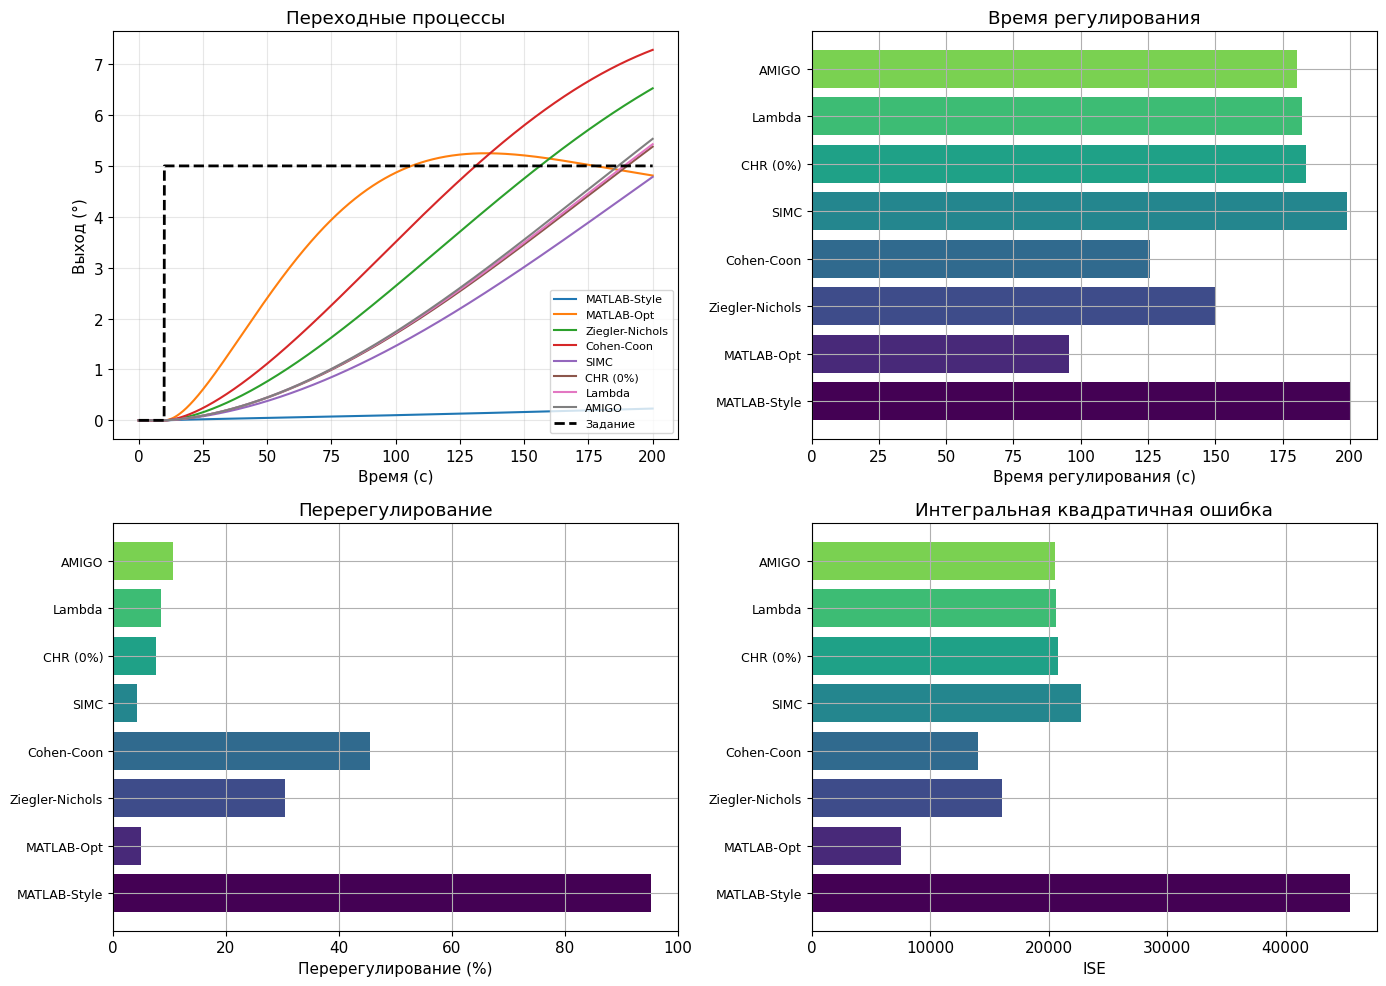


🏆 Лучший по времени регулирования: MATLAB-Opt
🏆 Лучший по перерегулированию: SIMC
🏆 Лучший по ISE: MATLAB-Opt


In [25]:
# Compare all methods
tuner.compare_methods()


## 🎯 Detailed Analysis of the Best Method



🎯 Детальный анализ: MATLAB-Opt

Параметры PID:
   Kp = -2.998339
   Ki = 0.005651
   Kd = -49.979213
   Ti = Kp/Ki = -530.619077 с
   Td = Kd/Kp = 16.668968 с

Метрики качества:
   Время регулирования: 95.70 с
   Перерегулирование: 4.97%
   Статическая ошибка: 0.1075°
   ISE: 7537.29
   ITAE: 103333.67


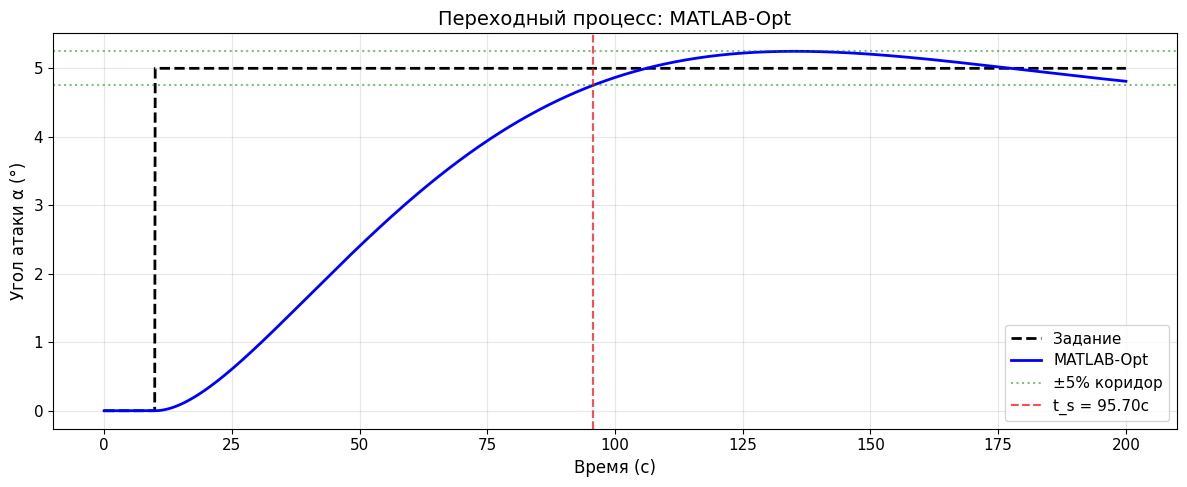

In [26]:
# Select the best method and perform detailed analysis
best_method = 'MATLAB-Opt'  # Can be changed to another one
best_params = tuner.tuning_results.get(best_method)

if best_params:
    print(f"\n🎯 Detailed analysis: {best_params.method}")
    print("="*60)
    print(f"\nPID parameters:")
    print(f"   Kp = {best_params.Kp:.6f}")
    print(f"   Ki = {best_params.Ki:.6f}")
    print(f"   Kd = {best_params.Kd:.6f}")
    print(f"   Ti = Kp/Ki = {best_params.Ti:.6f} s")
    print(f"   Td = Kd/Kp = {best_params.Td:.6f} s")
    
    result = tuner.simulate_pid(best_params)
    
    print(f"\nQuality metrics:")
    print(f"   Settling time: {result.settling_time:.2f} s")
    print(f"   Overshoot: {result.overshoot:.2f}%")
    print(f"   Steady-state error: {result.static_error:.4f}°")
    print(f"   ISE: {result.ise:.2f}")
    print(f"   ITAE: {result.itae:.2f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(result.time, result.reference, 'k--', linewidth=2, label='Reference')
    ax.plot(result.time, result.response, 'b-', linewidth=2, label=f'{best_params.method}')
    ax.axhline(y=result.reference[-1] * 0.95, color='g', linestyle=':', alpha=0.5, label='±5% band')
    ax.axhline(y=result.reference[-1] * 1.05, color='g', linestyle=':', alpha=0.5)
    ax.axvline(x=result.settling_time, color='r', linestyle='--', alpha=0.7, label=f't_s = {result.settling_time:.2f}s')
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Angle of attack α (°)', fontsize=12)
    ax.set_title(f'Transient response: {best_params.method}', fontsize=14)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 🔧 Manual Parameter Tuning


In [23]:
def test_custom_pid(Kp, Ki, Kd):
    """Test user-defined PID parameters."""
    params = PIDParams(Kp=Kp, Ki=Ki, Kd=Kd, method="Custom")
    result = tuner.simulate_pid(params)
    
    print(f"\n📊 Results for Kp={Kp}, Ki={Ki}, Kd={Kd}:")
    print(f"   Settling time: {result.settling_time:.2f} s")
    print(f"   Overshoot: {result.overshoot:.2f}%")
    print(f"   Steady-state error: {result.static_error:.4f}°")
    print(f"   ISE: {result.ise:.2f}")
    
    plt.figure(figsize=(10, 4))
    plt.plot(result.time, result.reference, 'k--', linewidth=2, label='Reference')
    plt.plot(result.time, result.response, 'b-', linewidth=2, label='Response')
    plt.xlabel('Time (s)')
    plt.ylabel('Output')
    plt.title(f'Custom PID: Kp={Kp}, Ki={Ki}, Kd={Kd}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return result

# Example: test with parameters from Optuna
# result = test_custom_pid(Kp=-14.4, Ki=-17.0, Kd=-13.1)


---

## 📚 PID Tuning Methods Reference

### Ziegler-Nichols (1942)
- **Application**: Universal, fast response
- **Features**: Aggressive tuning, high overshoot (~25%)
- **Formulas**: Kp = 1.2τ/(Kθ), Ti = 2θ, Td = 0.5θ

### Cohen-Coon (1953)
- **Application**: FOPDT systems with significant delay
- **Features**: Accounts for θ/τ ratio
- **Advantages**: Better than Z-N for systems with delay

### SIMC - Skogestad (2003)
- **Application**: Industrial systems
- **Features**: Single tuning parameter (τc)
- **Advantages**: Good speed/robustness balance

### CHR (1952)
- **Application**: Optimal criterion-based response
- **Features**: Two modes: 0% or 20% overshoot
- **Advantages**: Predictable response

### Lambda/IMC
- **Application**: Smooth control
- **Features**: Minimal overshoot
- **Advantages**: Minimal actuator load

### AMIGO (2006)
- **Application**: Modern systems
- **Features**: Performance/robustness balance
- **Advantages**: Good robustness to uncertainties

---

## 📖 References

1. Ziegler, J.G., Nichols, N.B. (1942). "Optimum settings for automatic controllers"
2. Cohen, G.H., Coon, G.A. (1953). "Theoretical consideration of retarded control"
3. Skogestad, S. (2003). "Simple analytic rules for model reduction and PID controller tuning"
4. Åström, K.J., Hägglund, T. (2006). "Advanced PID Control"
5. MATLAB Documentation: "PID Tuner" and "pidtune" function
